<a href="https://colab.research.google.com/github/NaumJan/NaumJan/blob/main/fuel_refuel_detection_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Детекция заправок по датчику уровня топлива

На транспортном средстве установлен датчик уровня топлива (ДУТ). Телематический блок
раз в несколько секунд передаёт уровень, состояние зажигания, скорость и координаты.
Задача — по этому временному ряду определять моменты заправок. Это основа топливного
учёта в автопарке: без автоматической детекции баланс топлива сводят вручную по чекам.

Простое решение — порог на приросте уровня — работает плохо по трём причинам:

1. Датчик возвращает показания в условных единицах, зависящих от геометрии бака.
   Нужна тарировка в литры, своя для каждой машины.
2. Датчик запитан от зажигания: при выключенном двигателе он не передаёт
   ничего, а значительная часть заправок происходит именно так.
3. При работающем двигателе уровень колеблется на несколько литров из-за разгонов
   и уклонов, и медленная заправка похожа на этот шум.

Порядок работы:

1. Разбор данных, поиск заправки на графике.
2. Построение признаков и окон.
3. Обучение LSTM.
4. Расчёт метрик — точечных и событийных.
5. Сравнение с пороговым правилом.
6. Задание на самостоятельную работу.

Полный прогон ноутбука на Colab без GPU занимает около пяти минут.


## 1. Данные

Файл `fuel_5min.csv` — реальные данные автопарка: 50 машин, полгода работы
(июль–декабрь 2025), 6.1 млн исходных сообщений, свёрнутых в **5-минутные интервалы**.
Номера машин обезличены, координаты убраны.

| колонка | что это |
|---|---|
| `vehicle` | идентификатор ТС, `V01`…`V50` |
| `ts` | начало 5-минутного интервала |
| `fuel` | средний уровень топлива в литрах по валидным сообщениям интервала |
| `ign` | доля времени с включённым зажиганием, 0..1 |
| `speed` | средняя скорость |
| `n_msg` | сколько исходных сообщений попало в интервал |
| `label` | **0** — ничего, **1** — заправка с включённым двигателем, **2** — заправка с выключенным двигателем |
| `split` | `train` / `test`, разбиение по машинам |

**Про классы.** Наша цель — класс **1**. Класс 2 (заправка с выключенным двигателем) в этих данных
выглядит принципиально иначе: датчик молчал всю заправку, и в 5-минутном ряду от неё
остаётся только скачок уровня между двумя соседними интервалами. Мы его не выкидываем,
но и не считаем целевым — модель учится отличать все три состояния.

**Про разбиение.** `split` делит выборку **по машинам, а не по точкам**.
Если резать случайно по точкам, окна одного и того же события попадут и в train, и в test,
и метрика будет завышена. Не меняйте это разбиение.

Из обучающих машин мы дополнительно откладываем девять под валидацию: на ней
выбирается лучшая эпоха. Тест используется ровно один раз — для итогового замера.
Выбирать эпоху по тесту нельзя: результат окажется завышенным, а на новых машинах
модель сработает хуже, чем обещала метрика.


In [22]:
import os
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Откуда брать данные. Если ноутбук открыт из GitHub, ссылка уже прописана
# и ничего делать не нужно — файл скачается сам.
DATA_URL = "https://raw.githubusercontent.com/hehehelp123/fuel-refuel-lab/main/data/fuel_5min.csv"
LOCAL = "fuel_5min.csv"

if not os.path.exists(LOCAL):
    if DATA_URL and not DATA_URL.startswith("__"):
        print("качаю датасет...")
        urllib.request.urlretrieve(DATA_URL, LOCAL)
    else:
        # Запасной вариант: загрузить файл кнопкой вручную
        from google.colab import files
        uploaded = files.upload()
        LOCAL = list(uploaded)[0]

df = pd.read_csv(LOCAL, parse_dates=["ts"])
print("строк:", len(df), "| машин:", df.vehicle.nunique())
df.head()

строк: 85228 | машин: 50


,vehicle,ts,fuel,ign,speed,n_msg,label,split
0,V01,2025-07-31 04:30:00,0.000,0.0,0.00,1,0,train
1,V01,2025-07-31 04:35:00,20.947,0.0,10.42,16,0,train
2,V01,2025-07-31 04:40:00,20.525,0.0,27.52,40,0,train
3,V01,2025-07-31 04:45:00,20.000,0.0,30.43,25,0,train
4,V01,2025-07-31 04:50:00,20.000,0.0,19.88,34,0,train


In [23]:
def count_events(labels, positive=1):
    """Число непрерывных блоков нужного класса."""
    arr = np.asarray(labels) == positive
    padded = np.pad(arr, (1, 1), constant_values=False)
    return len(np.where(np.diff(padded))[0]) // 2


print("Распределение меток по интервалам:")
print(df.label.value_counts().sort_index().rename({0: "0 — ничего",
                                                   1: "1 — двигатель включён",
                                                   2: "2 — двигатель выключен"}))
print()
share = (df.label == 1).mean() * 100
print(f"Доля целевого класса: {share:.2f}%")
print()

for name, part in df.groupby("split"):
    ev = sum(count_events(g.label) for _, g in part.groupby("vehicle"))
    print(f"{name:5s}: машин {part.vehicle.nunique():2d}, интервалов {len(part):6d}, событий класса 1: {ev}")

Распределение меток по интервалам:
label
0 — ничего                82337
1 — двигатель включён      1544
2 — двигатель выключен     1347
Name: count, dtype: int64

Доля целевого класса: 1.81%

test : машин  5, интервалов   9965, событий класса 1: 124
train: машин 45, интервалов  75263, событий класса 1: 414


### 1.1. Смотрим на заправку глазами

Прежде чем обучать что-либо, полезно посмотреть, как событие выглядит в данных.
Найдём машину с самым большим числом событий и нарисуем одно из них.


машина V11: событий 26


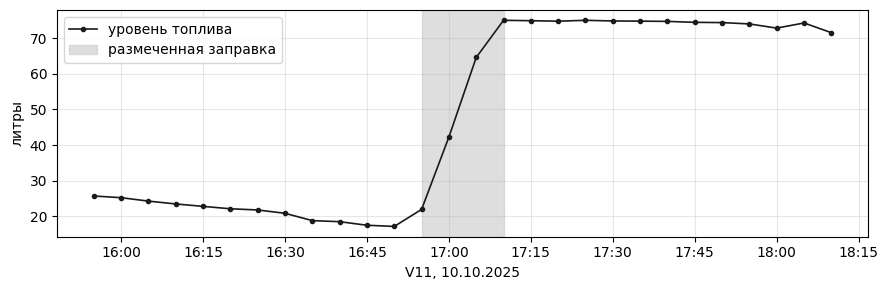

                 ts   fuel  ign  speed  n_msg  label
2025-10-10 15:55:00 25.694  1.0  89.55    136      0
2025-10-10 16:00:00 25.223  1.0  92.00    138      0
2025-10-10 16:05:00 24.264  1.0  87.78    137      0
2025-10-10 16:10:00 23.463  1.0  99.42    156      0
2025-10-10 16:15:00 22.789  1.0  81.39    100      0
2025-10-10 16:20:00 22.109  1.0  93.87    137      0
2025-10-10 16:25:00 21.777  1.0  84.54    123      0
2025-10-10 16:30:00 20.842  1.0  95.56    143      0
2025-10-10 16:35:00 18.783  1.0  87.29    129      0
2025-10-10 16:40:00 18.491  1.0  75.14    105      0
2025-10-10 16:45:00 17.486  1.0  70.79    107      0
2025-10-10 16:50:00 17.160  1.0  84.46    121      0
2025-10-10 16:55:00 21.929  1.0   5.32     17      1
2025-10-10 17:00:00 42.246  1.0  79.46    116      1
2025-10-10 17:05:00 64.567  1.0  79.09    143      1
2025-10-10 17:10:00 75.000  1.0  87.01    139      1
2025-10-10 17:15:00 74.888  1.0  37.60     67      0
2025-10-10 17:20:00 74.751  1.0  20.79     39 

In [24]:
def events_of(g, positive=1):
    """Границы блоков класса positive внутри одной машины: список (i_start, i_end)."""
    lab = (g.label.values == positive)
    out, start = [], None
    for i, v in enumerate(lab):
        if v and start is None:
            start = i
        elif not v and start is not None:
            out.append((start, i - 1))
            start = None
    if start is not None:
        out.append((start, len(lab) - 1))
    return out


top = (df[df.label == 1].groupby("vehicle").size().sort_values(ascending=False).index[0])
g = df[df.vehicle == top].reset_index(drop=True)
evts = events_of(g)
print(f"машина {top}: событий {len(evts)}")

s, e = evts[len(evts) // 2]                 # берём событие из середины списка
lo, hi = max(0, s - 12), min(len(g) - 1, e + 12)
w = g.iloc[lo:hi + 1]

plt.figure(figsize=(9, 3))
plt.plot(w.ts, w.fuel, marker="o", ms=3, lw=1.2, color="#1a1a1a", label="уровень топлива")
plt.axvspan(g.ts[s], g.ts[e], color="#c8c8c8", alpha=0.6, label="размеченная заправка")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.ylabel("литры")
plt.xlabel(f"{top}, {g.ts[s]:%d.%m.%Y}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(w[["ts", "fuel", "ign", "speed", "n_msg", "label"]].to_string(index=False))

Заправка выглядит как монотонный рост уровня на протяжении нескольких интервалов.
Модель должна научиться отличать такой рост от колебаний уровня и шума датчика.

Нули в столбце `fuel` — это интервалы, в которых датчик не передавал показания
(двигатель выключен). Это не пропуски данных, а информативный признак.


## 2. Признаки и окна

Признаки на один интервал — намеренно простые:

* `fuel` — сам уровень;
* `d1..d4` — разности с уровнем на 1, 2, 3 и 4 интервала назад.

Зачем четыре разности разной глубины: `d1` ловит резкий скачок между соседними интервалами,
`d4` — медленный рост, размазанный на 20 минут. Так сеть видит и то, и другое
без явного сглаживающего фильтра и без порогов, подобранных руками.

Дальше нарезаем **скользящие окна по 7 интервалов** (35 минут). Класс окна — это класс
его **центрального** интервала. Центр, а не конец, потому что для решения «была ли тут заправка»
одинаково полезен контекст и до, и после момента.


In [25]:
FEATURES = ["fuel", "d1", "d2", "d3", "d4"]
SEQ_LEN = 7          # длина окна в интервалах
CENTER = SEQ_LEN // 2


def add_features(g):
    g = g.sort_values("ts").copy()
    for k in (1, 2, 3, 4):
        g[f"d{k}"] = g["fuel"].diff(k).fillna(0.0)
    return g


df = df.groupby("vehicle", group_keys=False).apply(add_features)
df[["vehicle", "ts", "fuel"] + [f"d{k}" for k in (1, 2, 3, 4)]].head(8)

/tmp/ipykernel_659/1570497230.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("vehicle", group_keys=False).apply(add_features)


,vehicle,ts,fuel,d1,d2,d3,d4
0,V01,2025-07-31 04:30:00,0.000,0.000,0.000,0.000,0.000
1,V01,2025-07-31 04:35:00,20.947,20.947,0.000,0.000,0.000
2,V01,2025-07-31 04:40:00,20.525,-0.422,20.525,0.000,0.000
3,V01,2025-07-31 04:45:00,20.000,-0.525,-0.947,20.000,0.000
4,V01,2025-07-31 04:50:00,20.000,0.000,-0.525,-0.947,20.000
5,V01,2025-07-31 07:55:00,0.000,-20.000,-20.000,-20.525,-20.947
6,V01,2025-07-31 08:30:00,20.000,20.000,0.000,0.000,-0.525
7,V01,2025-07-31 08:35:00,20.000,0.000,20.000,0.000,0.000


In [26]:
def make_windows(frame):
    """Нарезает окна внутри каждой машины отдельно, чтобы не склеить разные ТС."""
    X, y, veh, ts = [], [], [], []
    for v, g in frame.groupby("vehicle"):
        vals = g[FEATURES].values.astype("float32")
        lab = g["label"].values.astype("int64")
        times = g["ts"].values
        for i in range(len(g) - SEQ_LEN + 1):
            X.append(vals[i:i + SEQ_LEN])
            y.append(lab[i + CENTER])
            veh.append(v)
            ts.append(times[i + CENTER])
    meta = pd.DataFrame({"vehicle": veh, "ts": pd.to_datetime(ts)})
    return np.asarray(X), np.asarray(y), meta


t0 = time.time()
# Из обучающих машин откладываем часть под валидацию: на ней выбираем эпоху.
# Тест трогаем ровно один раз — в конце. Если выбирать эпоху по тесту,
# результат будет завышен, и на новых машинах модель окажется хуже.
train_veh = sorted(df[df.split == "train"].vehicle.unique())
ev_per_veh = {v: count_events(df[df.vehicle == v].label) for v in train_veh}
VAL_VEH = set(sorted(train_veh, key=lambda v: -ev_per_veh[v])[1::5][:9])

X_train, y_train, meta_train = make_windows(
    df[df.split.eq("train") & ~df.vehicle.isin(VAL_VEH)])
X_val, y_val, meta_val = make_windows(df[df.vehicle.isin(VAL_VEH)])
X_test, y_test, meta_test = make_windows(df[df.split == "test"])
print(f"нарезка заняла {time.time() - t0:.1f} c")
print("train:", X_train.shape, "| валидация:", X_val.shape, "| test:", X_test.shape)
print("классы в train:", np.bincount(y_train))
print("классы в val  :", np.bincount(y_val))
print("классы в test :", np.bincount(y_test))

нарезка заняла 0.6 c
train: (59806, 7, 5) | валидация: (15187, 7, 5) | test: (9935, 7, 5)
классы в train: [57922   845  1039]
классы в val  : [14566   338   283]
классы в test : [9555  359   21]


## 3. Модель

Двухслойная LSTM на 64 скрытых нейрона, dropout 0.2 между слоями, сверху линейный слой
на 3 класса. Берём скрытое состояние последнего элемента окна.

Это ровно та архитектура, что крутится в проде, — чтобы обученную здесь модель можно
было забрать в рабочий сервис без переписывания.


In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("устройство:", DEVICE)


class FuelLSTM(nn.Module):
    def __init__(self, n_features=5, hidden=64, layers=2, n_classes=3, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden, n_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


model = FuelLSTM(n_features=len(FEATURES)).to(DEVICE)
print(model)
print("параметров:", sum(p.numel() for p in model.parameters()))

устройство: cpu
FuelLSTM(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)
параметров: 51651


### 3.1. Дисбаланс классов

Целевой класс занимает меньше 2% интервалов. Если ничего не делать, модель выучит
«всегда 0» и получит 98% accuracy, не найдя ни одной заправки.

Стандартный приём — веса классов в функции потерь. Но брать вес обратно
пропорционально частоте (`N_max / N_c`) здесь слишком грубо: вес улетает в десятки,
и модель начинает видеть заправки повсюду. Берём **корень** из этого отношения —
градиент от редкого класса становится заметным, но не доминирует.


In [28]:
def class_weights(y, n_classes=3, max_weight=30.0):
    counts = np.bincount(y, minlength=n_classes)
    majority = counts.max()
    w = [min(np.sqrt(majority / c), max_weight) if c > 0 else 0.0 for c in counts]
    return torch.tensor(w, dtype=torch.float32)


weights = class_weights(y_train)
for i, (c, wt) in enumerate(zip(np.bincount(y_train), weights)):
    print(f"класс {i}: {c:6d} примеров, вес {wt:.2f}")

класс 0:  57922 примеров, вес 1.00
класс 1:    845 примеров, вес 8.28
класс 2:   1039 примеров, вес 7.47


## 4. Обучение

In [29]:
EPOCHS = 30
BATCH = 512
LR = 1e-3

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)

criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                                                       factor=0.5, patience=2)

from sklearn.metrics import f1_score


def predict(loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            out = model(xb.to(DEVICE))
            preds.append(out.argmax(1).cpu().numpy())
    return np.concatenate(preds)


best_f1, best_state = -1.0, None
history = []                       # (эпоха, loss, F1) — пригодится для графика
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    total = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total += loss.item()

    val_pred = predict(val_loader)
    f1_target = f1_score(y_val, val_pred, labels=[1], average="macro", zero_division=0)
    scheduler.step(f1_target)
    history.append((epoch, total / len(train_loader), f1_target))

    if f1_target > best_f1:
        best_f1 = f1_target
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        mark = "  <- лучшая"
    else:
        mark = ""

    print(f"эпоха {epoch:2d} | loss {total / len(train_loader):.4f} | "
          f"F1 на валидации: {f1_target:.3f}{mark}")

model.load_state_dict(best_state)
print(f"\nобучение заняло {time.time() - t0:.0f} c, лучший F1 на валидации: {best_f1:.3f}")

эпоха  1 | loss 0.3757 | F1 на валидации: 0.563  <- лучшая
эпоха  2 | loss 0.2209 | F1 на валидации: 0.553
эпоха  3 | loss 0.1988 | F1 на валидации: 0.625  <- лучшая
эпоха  4 | loss 0.1865 | F1 на валидации: 0.645  <- лучшая
эпоха  5 | loss 0.1781 | F1 на валидации: 0.569
эпоха  6 | loss 0.1713 | F1 на валидации: 0.641
эпоха  7 | loss 0.1662 | F1 на валидации: 0.653  <- лучшая
эпоха  8 | loss 0.1623 | F1 на валидации: 0.657  <- лучшая
эпоха  9 | loss 0.1611 | F1 на валидации: 0.624
эпоха 10 | loss 0.1578 | F1 на валидации: 0.649
эпоха 11 | loss 0.1506 | F1 на валидации: 0.655
эпоха 12 | loss 0.1458 | F1 на валидации: 0.660  <- лучшая
эпоха 13 | loss 0.1443 | F1 на валидации: 0.659
эпоха 14 | loss 0.1439 | F1 на валидации: 0.674  <- лучшая
эпоха 15 | loss 0.1414 | F1 на валидации: 0.650
эпоха 16 | loss 0.1403 | F1 на валидации: 0.669
эпоха 17 | loss 0.1360 | F1 на валидации: 0.664
эпоха 18 | loss 0.1338 | F1 на валидации: 0.665
эпоха 19 | loss 0.1320 | F1 на валидации: 0.646
эпоха 20 | 

## 5. Метрики

### 5.1. Точечные метрики


                        precision    recall  f1-score   support

            0 — ничего      0.998     0.988     0.993      9555
 1 — двигатель включён      0.770     0.682     0.724       359
2 — двигатель выключен      0.120     0.857     0.211        21

              accuracy                          0.977      9935
             macro avg      0.629     0.843     0.642      9935
          weighted avg      0.988     0.977     0.982      9935



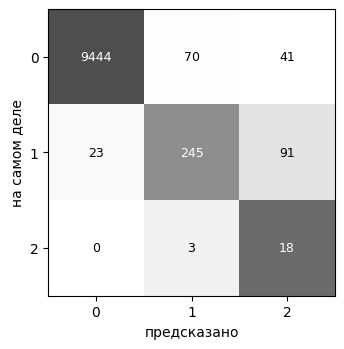

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = predict(test_loader)

names = ["0 — ничего", "1 — двигатель включён", "2 — двигатель выключен"]
print(classification_report(y_test, y_pred, target_names=names,
                            digits=3, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(4.2, 3.6))
ax.imshow(cm / cm.sum(axis=1, keepdims=True).clip(min=1), cmap="Greys", vmin=0, vmax=1.3)
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9,
                color="white" if cm[i, j] / max(cm[i].sum(), 1) > 0.55 else "black")
ax.set_xticks(range(3), ["0", "1", "2"])
ax.set_yticks(range(3), ["0", "1", "2"])
ax.set_xlabel("предсказано")
ax.set_ylabel("на самом деле")
ax.grid(False)
plt.tight_layout()
plt.show()

Класс 2 в тесте представлен всего парой десятков интервалов, поэтому его строчка
в отчёте шумная — не делайте по ней выводов. Целевой класс — первый.

### 5.2. Почему точечных метрик мало

Оператору автопарка не нужен ответ «этот пятиминутный интервал относится к заправке».
Ему нужно «14 августа в 10:05 машина V11 заправилась». Это **событие**, а не точка.

Разница существенная. Модель, которая на каждой заправке угадала 3 интервала из 5,
по точечной метрике выглядит средне, а по событийной — идеально: событие найдено.
И наоборот, модель, которая ровно один интервал посреди пустой стоянки пометила заправкой,
по точечной метрике почти не пострадает, а по событийной получит ложное срабатывание.

Считаем так: собираем предсказанные и эталонные события как непрерывные блоки класса 1
и сопоставляем их с допуском **±5 минут**. Предсказание, попавшее на класс 2,
не штрафуем — там разметке доверять нельзя.


In [31]:
TOLERANCE = np.timedelta64(5, "m")


def blocks(mask, times):
    """Непрерывные блоки True -> список (t_start, t_end)."""
    out, start = [], None
    for i, v in enumerate(mask):
        if v and start is None:
            start = i
        elif not v and start is not None:
            out.append((times[start], times[i - 1]))
            start = None
    if start is not None:
        out.append((times[start], times[len(mask) - 1]))
    return out


def event_metrics(y_true, y_pred, meta, verbose=True):
    n_true = n_true_hit = 0        # эталонные события и сколько из них найдено
    n_pred = n_pred_hit = 0        # предсказанные события и сколько попало в цель

    for v, sub in meta.groupby("vehicle"):
        pos = sub.index.to_numpy()          # meta идёт в том же порядке, что y_true/y_pred
        times = sub["ts"].values
        t_true = blocks(y_true[pos] == 1, times)
        t_pred = blocks(y_pred[pos] == 1, times)
        t_amb = blocks(y_true[pos] == 2, times)

        hit_true = set()
        for ps, pe in t_pred:
            hit = [k for k, (ts_, te_) in enumerate(t_true)
                   if ps <= te_ + TOLERANCE and pe >= ts_ - TOLERANCE]
            if hit:
                hit_true.update(hit)
                n_pred += 1
                n_pred_hit += 1
            elif any(ps <= te_ + TOLERANCE and pe >= ts_ - TOLERANCE
                     for ts_, te_ in t_amb):
                pass                      # попали в неоднозначную зону — не штрафуем
            else:
                n_pred += 1               # ложное срабатывание
        n_true += len(t_true)
        n_true_hit += len(hit_true)

    # событие засчитывается один раз, сколько бы кусков модель на него ни выдала
    tp, fn = n_true_hit, n_true - n_true_hit
    fp = n_pred - n_pred_hit
    precision = n_pred_hit / n_pred if n_pred else 0.0
    recall = n_true_hit / n_true if n_true else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    if verbose:
        print(f"события: TP={tp}  FP={fp}  FN={fn}")
        print(f"precision={precision:.3f}  recall={recall:.3f}  F1={f1:.3f}")
    return {"tp": tp, "fp": fp, "fn": fn,
            "precision": precision, "recall": recall, "f1": f1}


lstm_events = event_metrics(y_test, y_pred, meta_test)

события: TP=81  FP=1  FN=43
precision=0.988  recall=0.653  F1=0.786


## 6. С чем сравнивать: пороговое правило

Способ, который применяют по умолчанию, — порог на приросте уровня: если уровень
вырос больше чем на X литров за интервал, считаем это заправкой. Посмотрим, какой
результат он даёт на тех же данных. Это нижняя граница, с которой сравнивают модель.


In [32]:
# прирост уровня в центральном интервале окна — то, на что смотрит пороговое правило
d1_center = X_test[:, CENTER, FEATURES.index("d1")]

print(f"{'порог, л':>10} | {'precision':>9} | {'recall':>6} | {'F1':>5}")
print("-" * 42)
best_thr, best_thr_f1 = None, -1
thr_results = []
for thr in [1, 2, 3, 5, 8, 12, 20]:
    pred_thr = (d1_center > thr).astype("int64")
    m = event_metrics(y_test, pred_thr, meta_test, verbose=False)
    thr_results.append((thr, m))
    print(f"{thr:>10} | {m['precision']:>9.3f} | {m['recall']:>6.3f} | {m['f1']:>5.3f}")
    if m["f1"] > best_thr_f1:
        best_thr_f1, best_thr = m["f1"], thr

print(f"\nлучший порог: {best_thr} л, событийный F1 = {best_thr_f1:.3f}")
print(f"LSTM:                событийный F1 = {lstm_events['f1']:.3f}")

  порог, л | precision | recall |    F1
------------------------------------------
         1 |     0.164 |  1.000 | 0.282
         2 |     0.191 |  1.000 | 0.321
         3 |     0.207 |  1.000 | 0.344
         5 |     0.220 |  0.992 | 0.361
         8 |     0.226 |  0.992 | 0.367
        12 |     0.230 |  0.992 | 0.373
        20 |     0.213 |  0.758 | 0.332

лучший порог: 12 л, событийный F1 = 0.373
LSTM:                событийный F1 = 0.786


## 7. Итог бейзлайна

Ячейка ниже собирает метрики бейзлайна в один отчёт.


In [33]:
from sklearn.metrics import precision_score, recall_score

def report(y_true, y_pred, meta, title="модель"):
    p = precision_score(y_true, y_pred, labels=[1], average="macro", zero_division=0)
    r = recall_score(y_true, y_pred, labels=[1], average="macro", zero_division=0)
    f = f1_score(y_true, y_pred, labels=[1], average="macro", zero_division=0)
    macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    ev = event_metrics(y_true, y_pred, meta, verbose=False)
    print(f"=== {title} ===")
    print(f"точечные (класс 1): precision={p:.3f}  recall={r:.3f}  F1={f:.3f}")
    print(f"macro F1 по трём классам: {macro:.3f}")
    print(f"событийные: TP={ev['tp']} FP={ev['fp']} FN={ev['fn']}  "
          f"precision={ev['precision']:.3f} recall={ev['recall']:.3f} F1={ev['f1']:.3f}")
    return {"point_f1": f, "event_f1": ev["f1"]}


baseline = report(y_test, y_pred, meta_test, "LSTM baseline")

=== LSTM baseline ===
точечные (класс 1): precision=0.770  recall=0.682  F1=0.724
macro F1 по трём классам: 0.642
событийные: TP=81 FP=1 FN=43  precision=0.988 recall=0.653 F1=0.786


In [34]:
from numpy.lib.stride_tricks import sliding_window_view

def prep_df(frame):
    frame = frame.sort_values(["vehicle", "ts"]).copy()
    gap = frame.groupby("vehicle")["ts"].diff().dt.total_seconds().div(300)   # пропуск в интервалах
    frame["dt"] = np.log1p(gap.fillna(50).clip(upper=50))
    h = frame["ts"].dt.hour + frame["ts"].dt.minute / 60
    frame["hs"], frame["hc"] = np.sin(2 * np.pi * h / 24), np.cos(2 * np.pi * h / 24)
    return frame

df2 = prep_df(df)

def make_windows2(frame, feats, seq_len):
    center = seq_len // 2
    X, y, veh, ts = [], [], [], []
    for v, g in frame.groupby("vehicle"):
        n = len(g)
        if n < seq_len:
            continue
        vals = g[feats].values.astype("float32")
        X.append(sliding_window_view(vals, (seq_len, len(feats)))[:, 0])
        sl = slice(center, n - seq_len + 1 + center)
        y.append(g["label"].values[sl].astype("int64"))
        veh.append(np.full(n - seq_len + 1, v))
        ts.append(g["ts"].values[sl])
    meta = pd.DataFrame({"vehicle": np.concatenate(veh),
                         "ts": pd.to_datetime(np.concatenate(ts))})
    return np.concatenate(X), np.concatenate(y), meta

In [35]:
FEATS_BASE = ["fuel", "d1", "d2", "d3", "d4"]
FEATS_FULL = FEATS_BASE + ["dt", "ign", "speed", "n_msg"]

def proba(model, X):
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X), 2048):
            xb = torch.from_numpy(X[i:i + 2048]).to(DEVICE)
            out.append(torch.softmax(model(xb), 1).cpu().numpy())
    return np.concatenate(out)

def decode(P, t):
    pred = P.argmax(1)
    pred[P[:, 1] > t] = 1          # класс 1, если его вероятность выше порога t
    return pred

def run_experiment(feats, seq_len=7, normalize=True, power=0.5,
                   epochs=30, seed=42, name=""):
    torch.manual_seed(seed); np.random.seed(seed)
    Xtr, ytr, _ = make_windows2(df2[(df2.split == "train") & ~df2.vehicle.isin(VAL_VEH)], feats, seq_len)
    Xv, yv, mv = make_windows2(df2[df2.vehicle.isin(VAL_VEH)], feats, seq_len)
    Xte, yte, mte = make_windows2(df2[df2.split == "test"], feats, seq_len)

    if normalize:                                  # статистики только по train
        flat = Xtr.reshape(-1, len(feats))
        mu, sd = flat.mean(0), flat.std(0) + 1e-6
        Xtr, Xv, Xte = [((X - mu) / sd).astype("float32") for X in (Xtr, Xv, Xte)]

    counts = np.bincount(ytr, minlength=3)
    w = torch.tensor([min((counts.max() / c) ** power, 30.0) if c else 0.0 for c in counts],
                     dtype=torch.float32)

    mdl = FuelLSTM(n_features=len(feats)).to(DEVICE)
    crit = nn.CrossEntropyLoss(weight=w.to(DEVICE))
    opt = torch.optim.Adam(mdl.parameters(), lr=1e-3)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)
    loader = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
                        batch_size=512, shuffle=True)

    best, best_state = -1.0, None
    for ep in range(epochs):
        mdl.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); crit(mdl(xb), yb).backward(); opt.step()
        f1v = f1_score(yv, proba(mdl, Xv).argmax(1), labels=[1], average="macro", zero_division=0)
        sch.step(f1v)
        if f1v > best:                              # эпоха выбирается по валидации
            best = f1v
            best_state = {k: v.cpu().clone() for k, v in mdl.state_dict().items()}
    mdl.load_state_dict(best_state)

    Pv, Pte = proba(mdl, Xv), proba(mdl, Xte)
    # порог подбираем ТОЛЬКО по валидации; при равенстве берём больший порог
    grid = np.round(np.arange(0.05, 0.951, 0.05), 2)
    scores = [event_metrics(yv, decode(Pv, t), mv, verbose=False)["f1"] for t in grid]
    t_best = grid[max(range(len(grid)), key=lambda i: (scores[i], grid[i]))]

    res = dict(name=name, thr=t_best, val_event_f1=max(scores),
               test_event_f1_argmax=event_metrics(yte, decode(Pte, 0.5), mte, verbose=False)["f1"],
               test_event_f1_tuned=event_metrics(yte, decode(Pte, t_best), mte, verbose=False)["f1"],
               y_test=yte, meta_test=mte, pred_tuned=decode(Pte, t_best))
    print(f"{name:34s} | порог {t_best:.2f} | val {res['val_event_f1']:.3f} | "
          f"test event F1: argmax {res['test_event_f1_argmax']:.3f} -> с порогом {res['test_event_f1_tuned']:.3f}")
    return res

In [36]:
results = [
    run_experiment(FEATS_BASE, 7, normalize=False, name="0. как в бейзлайне (пересчёт)"),
    run_experiment(FEATS_FULL, 7, normalize=False, name="1. + dt, ign, speed, n_msg"),
    run_experiment(FEATS_FULL, 7, normalize=True,  name="2. + стандартизация"),
    run_experiment(FEATS_FULL, 9, normalize=True,  name="3. + окно 9 интервалов"),
    run_experiment(FEATS_FULL, 13, normalize=True, name="4. окно 13 интервалов"),
]
table = pd.DataFrame([{k: v for k, v in r.items() if k not in ("y_test", "meta_test", "pred_tuned")}
                      for r in results])
table

0. как в бейзлайне (пересчёт)      | порог 0.10 | val 0.961 | test event F1: argmax 0.798 -> с порогом 0.975
1. + dt, ign, speed, n_msg         | порог 0.05 | val 0.962 | test event F1: argmax 0.855 -> с порогом 0.975
2. + стандартизация                | порог 0.10 | val 0.989 | test event F1: argmax 0.893 -> с порогом 0.996
3. + окно 9 интервалов             | порог 0.10 | val 0.983 | test event F1: argmax 0.830 -> с порогом 0.988
4. окно 13 интервалов              | порог 0.05 | val 0.961 | test event F1: argmax 0.825 -> с порогом 0.983


,name,thr,val_event_f1,test_event_f1_argmax,test_event_f1_tuned
0,0. как в бейзлайне (пересчёт),0.10,0.960894,0.798211,0.975410
1,"1. + dt, ign, speed, n_msg",0.05,0.961626,0.854863,0.975443
2,2. + стандартизация,0.10,0.988636,0.892857,0.995984
3,3. + окно 9 интервалов,0.10,0.983240,0.830276,0.987853
4,4. окно 13 интервалов,0.05,0.960515,0.824689,0.983471


In [37]:
best = max(results, key=lambda r: r["val_event_f1"])          # выбор по валидации, не по тесту
print("выбрана конфигурация:", best["name"], "| порог", best["thr"])
final = report(best["y_test"], best["pred_tuned"], best["meta_test"], "LSTM улучшенная")
print(f"\nevent_f1: бейзлайн {baseline['event_f1']:.3f} -> {final['event_f1']:.3f}")
print(f"point_f1: бейзлайн {baseline['point_f1']:.3f} -> {final['point_f1']:.3f}")

выбрана конфигурация: 2. + стандартизация | порог 0.1
=== LSTM улучшенная ===
точечные (класс 1): precision=0.487  recall=0.964  F1=0.647
macro F1 по трём классам: 0.594
событийные: TP=124 FP=1 FN=0  precision=0.992 recall=1.000 F1=0.996

event_f1: бейзлайн 0.786 -> 0.996
point_f1: бейзлайн 0.724 -> 0.647


In [38]:
Xf, yf, mf = make_windows2(df2[df2.split == "test"], ["d1", "dt"], 7)
d1c, dtc = Xf[:, CENTER, 0], Xf[:, CENTER, 1]
adjacent = dtc < np.log1p(1) + 1e-6          # предыдущая строка — соседний интервал
for thr in [5, 8, 12, 15, 20]:
    m = event_metrics(yf, ((d1c > thr) & adjacent).astype("int64"), mf, verbose=False)
    print(thr, f"P={m['precision']:.3f} R={m['recall']:.3f} F1={m['f1']:.3f}")

5 P=0.558 R=0.992 F1=0.714
8 P=0.561 R=0.992 F1=0.716
12 P=0.563 R=0.992 F1=0.718
15 P=0.577 R=0.976 F1=0.725
20 P=0.540 R=0.750 F1=0.628


## 8. Задание

**Цель: увеличить событийный F1 на тестовых машинах.** Бейзлайн — 0.786, планка «хорошо» — выше 0.90.

Главная метрика — `event_f1` из отчёта выше. Вторая метрика — точечный F1 по классу 1;
её тоже указывайте, чтобы было видно, за счёт чего вырос результат.

### Правила

1. Разбиение `split` не трогаем. Обучаться на машинах из `test` нельзя.
2. Метки в тесте не меняем.
3. Гиперпараметры подбираем на train (можно отрезать часть train-машин под валидацию).
   Если крутить их прямо по тесту, вы просто переобучитесь на пять машин.
4. В отчёте — таблица «что поменял → какой стал event_f1», а не только финальное число.

### Что можно попробовать

От простого к сложному:

* **Признаки.** Сейчас используется только уровень и четыре разности. В данных есть
  `ign`, `speed`, `n_msg`, время суток. Заправка с включённым двигателем — это почти всегда малая скорость
  при включённом зажигании. Помогает ли это?
* **Нормализация.** Признаки поданы в сыром виде: уровень в литрах (0–100), разности около нуля.
  Попробуйте стандартизацию — статистики считайте **только по train**.
* **Длина окна.** 7 интервалов = 35 минут. Длиннее — больше контекста и меньше окон; короче — наоборот.
* **Веса классов.** Мы взяли корень из отношения частот. Попробуйте другую степень,
  focal loss или пересэмплирование.
* **Архитектура.** Двунаправленная LSTM, GRU, одномерная свёртка, attention над окном.
  Модель крошечная — экспериментировать дёшево.
* **Постобработка.** Одиночный интервал класса 1 среди нулей, скорее всего, ложное
  срабатывание. Сглаживание предсказаний или требование минимальной длины события
  нередко даёт больше, чем смена архитектуры.
* **Порог решения.** `argmax` — не догма. Возьмите вероятность класса 1 и подберите порог
  под нужный баланс precision/recall.
* **Другой размер интервала.** Файл `fuel_raw.csv.gz` содержит исходные сообщения.
  5 минут — это наш выбор, а не закон природы.

### Что сдавать

Ноутбук, в котором:

1. воспроизводится бейзлайн (можно ссылкой на этот),
2. реализовано ваше улучшение,
3. в конце вызван `report(...)` — сравнение с бейзлайном по обеим метрикам,
4. есть короткий разбор: что сработало, что нет и почему вы так думаете.

### Отдельный вопрос со звёздочкой

В том же проекте есть вторая модель — для заправок с выключенным двигателем.
На тесте она даёт **accuracy 100% и F1 = 1.0** по целевому классу.

Её задача устроена так. Когда двигатель заглушен, датчик молчит, и в данных
остаётся провал. Всего таких провалов **11 758**, из них эксперт отметил заправками
**711**. Модель должна отличить одни от других по уровню до провала и после.

Возьмите разницу «уровень после минус уровень до» и поставьте на неё порог.
У заправок эта разница в среднем 36 литров, у обычных стоянок — ноль.

Вопросы:

1. Какой F1 даёт простой порог на этой разнице? (у нас вышло 0.968 при пороге 15 л)
2. Сколько тогда добавляет нейросеть поверх одного вычитания?
3. Что означает её «стопроцентная точность» и что нужно поменять, чтобы
   число стало осмысленным?
